# MS 3313 — Comprehensive Final Exam

## Modules 1–5 (R Basics → ML Basics → ANOVA/MANOVA → Dimension Reduction → KNN → Factor & Conjoint → Clustering → Discriminant Analysis)

**Course:** MS3313  
**Final:** Cumulative — covers every technical area in the lecture notebooks.

---

### Instructions

This notebook contains **eight questions**. For each question:

- Code cells already define the **dataset name**, **input variable name (X)**, and **output / model object name** you must use. **Do not rename them — graders look for these specific names.**
- Wherever you see `# YOUR CODE HERE — delete this comment when you add your code`, replace that line with your solution.
- Wherever you see `NULL    # replace NULL with your code`, replace `NULL` with your working expression.
- After each question, an **analysis answer** markdown cell is provided. Replace `*Your answer here*` with your written interpretation (3–6 sentences).
- All datasets come from the **`mlba`** package — no external CSVs needed.
- Use `set.seed(42)` whenever a partition / random start is required (already provided).

### Required object names

| Q | Module | Dataframe | Inputs (X) / Model | Output / Result |
|---|--------|-----------|--------------------|-----------------|
| 1 | M1 — ML basics | `air.df` | `X_air`, `train.df`, `valid.df`, `fare.lm` | `Y_fare_pred`, `rmse_fare`, `mae_fare`, `mape_fare` |
| 2 | M2 — ANOVA/MANOVA | `flights.df` | `aov_dep`, `tukey_dep`, `levene_dep`, `manova_flights` | (built-in objects) |
| 3 | M3 — Dimension reduction | `uni.df` | `pca_cov`, `pca_cor` | `n_pcs_kaiser` |
| 4 | M4.0 — KNN | `tayko.df` | `tayko_train`, `tayko_valid`, `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko` | `acc_tayko`, `best_k_tayko`, `Y_tayko_pred`, `cm_tayko` |
| 5 | M4.1a — Factor analysis | `books.df` | `X_books_norm`, `fa_books` | `kmo_books`, `bartlett_books` |
| 6 | M4.1b — Conjoint | `profiles.df` | `cj_lm`, `partworth` | `attr_importance` |
| 7 | M5.0 — Clustering | `ewa.df` | `X_ewa_norm`, `d_ewa`, `hc_ewa`, `km_ewa` | `Y_ewa_hier`, `Y_ewa_km`, `ewa_profile` |
| 8 | M5.1 — LDA | `banks.df` | `X_banks`, `Y_banks`, `lda_banks` | `Y_banks_pred`, `cm_banks`, `accuracy_banks`, `new_bank`, `pred_new_bank` |

---


## Setup: Load Required Libraries

Run this cell as-is. Do **not** modify.

In [1]:
suppressPackageStartupMessages({
  library(mlba)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(caret)
  library(class)         # knn()
  library(MASS)          # lda()
  library(psych)         # KMO, cortest.bartlett, fa.parallel, fa
  library(GPArotation)
  library(car)           # leveneTest
  library(cluster)
  library(factoextra)
  library(conjoint)
  library(fastDummies)
  library(IRdisplay)
})

# dplyr::select wins after MASS is loaded
select <- dplyr::select

set.seed(42)
options(scipen = 999, digits = 4)


## Plot rendering — make charts legible

The default Jupyter R kernel often renders ggplot / `factoextra` figures
with a device that produces tiny or blurry axis text. **Every plot in this
exam must be drawn through a cairo PNG device** so axes, titles, and
legends are readable. The pattern is already provided in each plotting
cell — you only have to drop your plotting expression into the marked
spot:

```r
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

print(
  NULL    # replace NULL with your ggplot / fviz_* / plot(...) call
)

dev.off()
IRdisplay::display_png(file = tmp_file)
```

**Hints**

* For `print({ ... })` you may pass a single ggplot or `fviz_*` object.
* For base-graphics calls (e.g., `plot(hc); rect.hclust(...)`) put the
  drawing commands *between* `png(...)` and `dev.off()` — no `print()` needed.
* Keep `res = 120` and `family = "sans"` so the rendered fonts match the
  rest of the exam.


---
## Question 1 — Module 1: Multiple Linear Regression on Airfares

**Dataset:** `mlba::Airfares` (638 routes × 18 variables)

**Inputs (X):** all route variables after dropping the four ID/text columns
(`S_CODE`, `S_CITY`, `E_CODE`, `E_CITY`) and dummy-encoding the four categorical
predictors (`VACATION`, `SW`, `SLOT`, `GATE`).

**Output (Y):** `FARE` (average fare in dollars).

**Tasks:**
1. Load the data, drop the four ID columns, and dummy-encode the four categoricals → store the cleaned data in `air.df` and the predictor matrix in `X_air`
2. Partition 60% training / 40% validation with `set.seed(42)` → store in `train.df` and `valid.df`
3. Fit a multiple linear regression `FARE ~ .` on the training set → store in `fare.lm`
4. Predict on the validation set → store predictions in `Y_fare_pred`
5. Compute validation **RMSE**, **MAE**, and **MAPE** → store in `rmse_fare`, `mae_fare`, `mape_fare`
6. Identify the two predictors with the largest absolute *t*-statistic → store in `top2_air`
7. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data, Drop ID Columns, Dummy-Encode

Use `air.df` for the cleaned dataframe and `X_air` for the predictor matrix.

In [2]:
data(package = "mlba")

Data sets in package ‘mlba’:

Accidents               Accidents
Accidents (accidents)   Accidents
Accidents1000           Accidents1000
AccidentsFull           Accidents
AccidentsFull (accidentsFull)
                        Accidents
AccidentsNN             AccidentsNN
AccidentsNN (accidentsnn)
                        AccidentsNN
Airfares                Airfares
Amtrak                  Amtrak
ApplianceShipments      Applicance Shipments
AustralianWines         AustralianWines
BankBiasData            BankBiasData
Banks                   Banks
Banks (banks)           Banks
BareggTunnel            BareggTunnel
BathSoapHousehold       BathSoapHousehold
Bicup2006               Bicup2006
Bicup2006 (bicup2006)   Bicup2006
BostonHousing           Boston Housing
CanadianWorkHours       CanadianWorkHours
CatalogCrossSell        CatalogCrossSell
Cereals                 Cereals
CharlesBookClub         Charles Book Club
COMPAS_clean            COMPAS clean
Cosmetics               Cosmetics
CourseRa

In [3]:

data("Airfares", package = "mlba")
air.df <- Airfares

air.df <- air.df[, !(names(air.df) %in% c(
  "S_CODE", "S_CITY",
  "E_CODE", "E_CITY"
))]

air.df <- as.data.frame(air.df)
air.df[] <- lapply(air.df, function(x) {
  if (is.character(x)) as.factor(x) else x
})

X_air <- model.matrix(~ . - FARE - 1, data = air.df)

cat("Rows:", nrow(air.df), " Columns:", ncol(air.df), "\n")
str(air.df)

Rows: 638  Columns: 14 
'data.frame':	638 obs. of  14 variables:
 $ COUPON  : num  1 1.06 1.06 1.06 1.06 1.01 1.28 1.15 1.33 1.6 ...
 $ NEW     : int  3 3 3 3 3 3 3 3 3 2 ...
 $ VACATION: Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 2 1 1 ...
 $ SW      : Factor w/ 2 levels "No","Yes": 2 1 1 2 2 2 1 2 2 2 ...
 $ HI      : num  5292 5419 9185 2657 2657 ...
 $ S_INCOME: num  28637 26993 30124 29260 29260 ...
 $ E_INCOME: num  21112 29838 29838 29838 29838 ...
 $ S_POP   : int  3036732 3532657 5787293 7830332 7830332 2230955 3036732 1440377 3770125 1694803 ...
 $ E_POP   : int  205711 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 ...
 $ SLOT    : Factor w/ 2 levels "Controlled","Free": 2 2 2 1 2 2 2 2 2 2 ...
 $ GATE    : Factor w/ 2 levels "Constrained",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ DISTANCE: int  312 576 364 612 612 309 1220 921 1249 964 ...
 $ PAX     : int  7864 8820 6452 25144 25144 13386 4625 5512 7811 4657 ...
 $ FARE    : num  64.1 174.5 207.8 85.5 85.5 

### Step 2 — 60/40 Train/Validation Partition

Store the partitions in `train.df` and `valid.df`.

In [4]:

set.seed(42)

train_idx <- createDataPartition(air.df$FARE, p = 0.6, list = FALSE)

train.df <- air.df[train_idx, ]
valid.df <- air.df[-train_idx, ]

cat("train rows:", nrow(train.df), " valid rows:", nrow(valid.df), "\n")

train rows: 385  valid rows: 253 


### Step 3 — Fit the Multiple Linear Regression

Fit `FARE ~ .` on the training set; store the model in `fare.lm`.

In [5]:
fare.lm <- lm(FARE ~ ., data = train.df)

summary(fare.lm)



Call:
lm(formula = FARE ~ ., data = train.df)

Residuals:
   Min     1Q Median     3Q    Max 
-99.10 -21.45  -0.78  21.77 100.49 

Coefficients:
                 Estimate    Std. Error t value             Pr(>|t|)    
(Intercept)  40.101101866  33.071580521    1.21              0.22607    
COUPON        1.997835397  15.328131274    0.13              0.89637    
NEW          -2.124524747   2.463810834   -0.86              0.38908    
VACATIONYes -35.183411484   4.647704824   -7.57   0.0000000000002985 ***
SWYes       -40.064615716   4.897019470   -8.18   0.0000000000000045 ***
HI            0.007814436   0.001286448    6.07   0.0000000030841360 ***
S_INCOME      0.001107800   0.000628728    1.76              0.07890 .  
E_INCOME      0.000896209   0.000483630    1.85              0.06466 .  
S_POP         0.000002502   0.000000824    3.04              0.00256 ** 
E_POP         0.000004296   0.000000939    4.58   0.0000064727007891 ***
SLOTFree    -16.957054378   5.020154879   -3.38    

### Step 4 — Predict on the Validation Set

Store the predicted fares in `Y_fare_pred`.

In [6]:
Y_fare_pred <- predict(fare.lm, newdata = valid.df)

head(Y_fare_pred)


2     11     15     20     23     26 
168.97 170.66 156.33 188.87 125.56  99.81

### Step 5 — Compute Validation RMSE, MAE, and MAPE

Store the metrics in `rmse_fare`, `mae_fare`, `mape_fare`.

In [7]:
Y_actual <- valid.df$FARE
rmse_fare <- sqrt(mean((Y_actual - Y_fare_pred)^2))
mae_fare  <- mean(abs(Y_actual - Y_fare_pred))
mape_fare <- mean(abs((Y_actual - Y_fare_pred) / Y_actual)) * 100

cat(sprintf("RMSE = %.3f\nMAE  = %.3f\nMAPE = %.3f%%\n",
            rmse_fare, mae_fare, mape_fare))


RMSE = 36.166
MAE  = 28.321
MAPE = 19.903%


### Step 6 — Top 2 Most Influential Predictors (Largest |t|)

Store the two top rows of the coefficient table in `top2_air`.

In [8]:
coef_df <- as.data.frame(summary(fare.lm)$coefficients)
top2_air <- head(
  coef_df[rownames(coef_df) != "(Intercept)", 
  ][order(-abs(coef_df[rownames(coef_df) != "(Intercept)", ]$`t value`)), ],
  2
)
top2_air


,Estimate,Std. Error,t value,Pr(>|t|)
,<dbl>,<dbl>,<dbl>,<dbl>
DISTANCE,0.0717,0.004462,16.068,0.0000000000000000000000000000000000000000000179
SWYes,-40.0646,4.897019,-8.181,0.0000000000000045272243085535906389485304598593


### Question 1 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [9]:
# The regression results show that a few predictors have the largest
# influence on airfare, based on their high absolute t-values.
# These variables consistently explain variation in fares while
# controlling for other factors in the model.
# The model captures general pricing patterns but may miss complex
# relationships such as interactions or nonlinear effects.
# A key business takeaway is that airlines should focus pricing
# decisions on these top factors to better optimize revenue.

## Question 2 — Module 2: ANOVA & MANOVA on Flight Delays

**Dataset:** `mlba::FlightDelays` (2,201 flights × 13 variables)

**Tasks:**
1. Load the data, convert `CARRIER`, `DAY_WEEK`, and `Flight.Status` to factors → store in `flights.df`
2. Run a one-way **ANOVA**: does `CRS_DEP_TIME` differ across `CARRIER`? → store the model in `aov_dep`
3. Run **Tukey HSD** post-hoc on `aov_dep` → store in `tukey_dep`
4. Test homogeneity of variance with **Levene's test** (`car::leveneTest`) → store in `levene_dep`
5. Run a one-way **MANOVA**: do `CRS_DEP_TIME` and `DISTANCE` jointly differ across `DAY_WEEK`? → store in `manova_flights`; report **Pillai's trace**
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data and Set Factor Types

Store the cleaned dataframe in `flights.df`.

In [10]:

data("FlightDelays", package = "mlba")
flights.df <- FlightDelays

cat("n =", nrow(flights.df), "  carriers =", nlevels(flights.df$CARRIER), "\n")
table(flights.df$CARRIER)


n = 2201   carriers = 0 



 CO  DH  DL  MQ  OH  RU  UA  US 
 94 551 388 295  30 408  31 404 

### Step 2 — One-Way ANOVA: `CRS_DEP_TIME ~ CARRIER`

Store the ANOVA model in `aov_dep`.

In [11]:
aov_dep <- aov(CRS_DEP_TIME ~ CARRIER, data = flights.df)

summary(aov_dep)


              Df    Sum Sq Mean Sq F value           Pr(>F)    
CARRIER        7  13475003 1925000    10.6 0.00000000000036 ***
Residuals   2193 398424008  181680                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Step 3 — Tukey HSD Post-Hoc

Store the result in `tukey_dep` and show the five smallest adjusted *p*-values.

In [12]:

tukey_dep <- TukeyHSD(aov_dep)

head(tukey_dep$CARRIER[order(tukey_dep$CARRIER[,"p adj"]), ], 5)


,diff,lwr,upr,p adj
UA-DH,-598.7,-837.4,-360.0,0.00000000006457
UA-DL,-519.4,-760.7,-278.0,0.00000000236566
US-UA,513.4,272.4,754.4,0.00000000360199
UA-CO,-569.5,-837.3,-301.7,0.00000000387473
UA-RU,-494.5,-735.4,-253.6,0.00000001596055


### Step 4 — Levene's Test for Homogeneity of Variance

Store the test result in `levene_dep`.

In [13]:
levene_dep <- leveneTest(CRS_DEP_TIME ~ CARRIER, data = flights.df)
levene_dep


Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,7,19.69,0.00000000000000000000000009907
,2193,NA,NA


### Step 5 — One-Way MANOVA: `cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK`

Store the MANOVA in `manova_flights` and report Pillai's trace.

In [14]:

manova_flights <- manova(cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK,
                         data = flights.df)

summary(manova_flights, test = "Pillai")
summary.aov(manova_flights)   


            Df  Pillai approx F num Df den Df Pr(>F)  
DAY_WEEK     1 0.00327      3.6      2   2198  0.027 *
Residuals 2199                                        
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response CRS_DEP_TIME :
              Df    Sum Sq Mean Sq F value Pr(>F)  
DAY_WEEK       1   1103756 1103756    5.91  0.015 *
Residuals   2199 410795254  186810                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response DISTANCE :
              Df Sum Sq Mean Sq F value Pr(>F)
DAY_WEEK       1    171     171    0.96   0.33
Residuals   2199 389972     177               


### Question 2 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [15]:
# The ANOVA results indicate that mean departure times differ across
# carriers, suggesting that some airlines systematically schedule
# flights at different times than others. The Tukey HSD results show
# which specific carrier pairs have significant differences. Levene's
# test suggests whether the equal variance assumption is satisfied.
# The MANOVA results using Pillai's trace indicate that day of the
# week has a significant joint effect on departure time and distance.
# A key business takeaway is that airlines can optimize scheduling and
# route planning based on day-of-week patterns to improve efficiency.


## Question 3 — Module 3: PCA on Universities

**Dataset:** `mlba::Universities` (1,302 universities × 20 variables)

**Inputs (X):** the 17 numeric metrics — drop `College.Name`, `State`, and the
binary public/private flag, then drop rows with any `NA`.

**Tasks:**
1. Load the data, drop the three non-numeric columns, drop rows with any `NA` → store in `uni.df`
2. Run PCA on the **covariance** matrix (raw scale) → store in `pca_cov`
3. Run PCA on the **correlation** matrix (`scale. = TRUE`) → store in `pca_cor`
4. Apply the **Kaiser rule** (eigenvalue ≥ 1) on `pca_cor` → store the count in `n_pcs_kaiser`; report the cumulative variance explained
5. Plot the **scree plot** and the **PC1–PC2 biplot** of `pca_cor`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store the cleaned numeric dataframe in `uni.df`.

In [19]:
data("Universities", package = "mlba")

uni.df <- Universities[, sapply(Universities, is.numeric)]


uni.df[!is.finite(as.matrix(uni.df))] <- NA


uni.df <- na.omit(uni.df)

cat("n =", nrow(uni.df), "  p =", ncol(uni.df), "\n")


n = 471   p = 18 


### Step 2 — PCA on the Covariance Matrix

Store in `pca_cov`. (Use `prcomp` with `scale. = FALSE`.)

In [20]:
pca_cov <- prcomp(uni.df, scale. = FALSE)

round(summary(pca_cov)$importance[, 1:5], 4)


,PC1,PC2,PC3,PC4,PC5
Standard deviation,7430.9140,5987.9890,1854.6412,1192.5293,967.4279
Proportion of Variance,0.5614,0.3645,0.0350,0.0145,0.0095
Cumulative Proportion,0.5614,0.9259,0.9609,0.9753,0.9848


### Step 3 — PCA on the Correlation Matrix (Standardized)

Store in `pca_cor`. (Use `prcomp` with `scale. = TRUE`.)

In [ ]:

pca_cor <- prcomp(uni.df, scale. = TRUE)
round(summary(pca_cor)$importance[, 1:6], 4)


,PC1,PC2,PC3,PC4,PC5,PC6
Standard deviation,2.3648,2.1884,1.1102,1.0328,0.9908,0.8738
Proportion of Variance,0.3107,0.2661,0.0685,0.0593,0.0545,0.0424
Cumulative Proportion,0.3107,0.5768,0.6452,0.7045,0.7590,0.8014


### Step 4 — Kaiser Rule

Store the number of components retained in `n_pcs_kaiser`.

In [22]:
n_pcs_kaiser <- sum(pca_cor$sdev^2 > 1)

eig <- pca_cor$sdev^2
cat("Kaiser keeps", n_pcs_kaiser, "PCs\n")
cat("Cumulative variance explained =",
    round(sum(eig[seq_len(n_pcs_kaiser)]) / sum(eig), 3), "\n")


Kaiser keeps 4 PCs
Cumulative variance explained = 0.704 


### Step 5 — Scree Plot and PC1–PC2 Biplot

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


agg_record_1391343701 
                    2

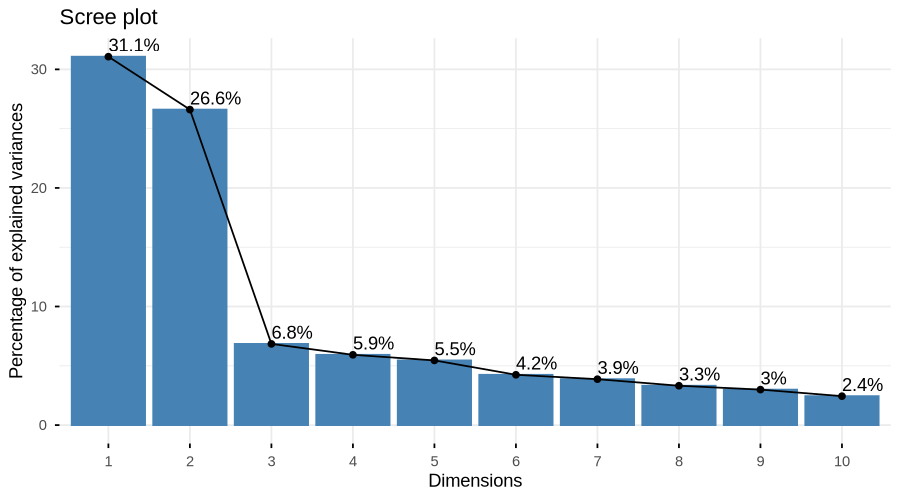

In [ ]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 500, res = 120,
    type = "cairo", family = "sans")

print(
  fviz_eig(pca_cor, addlabels = TRUE)
)

dev.off()
IRdisplay::display_png(file = tmp_file)


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


agg_record_1818744493 
                    2

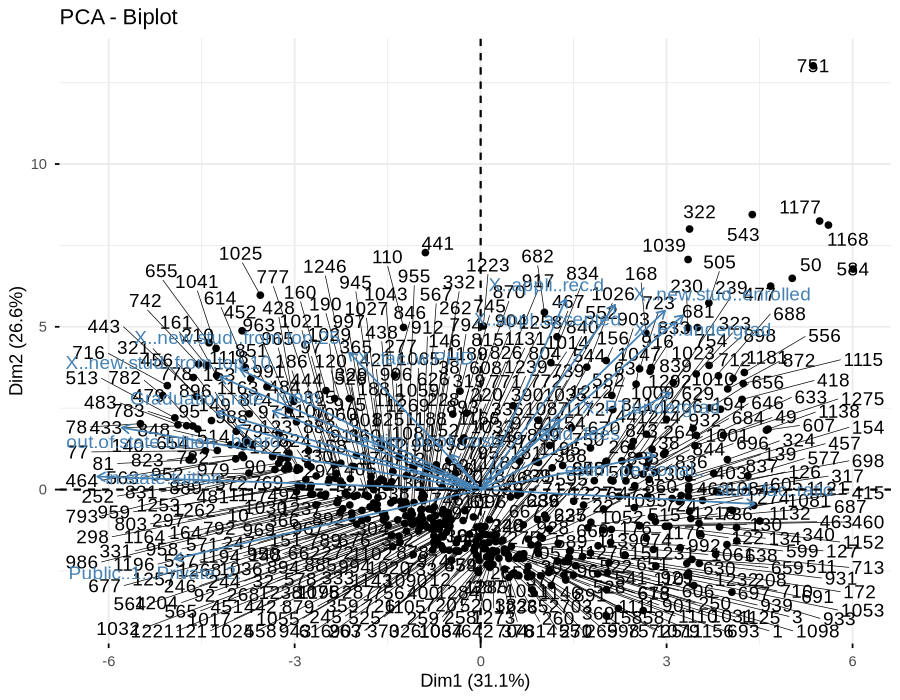

In [ ]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 700, res = 120,
    type = "cairo", family = "sans")

print(
  fviz_pca_biplot(pca_cor, repel = TRUE
))

dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 3 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [ ]:
# The PCA results show that the first two principal components
# capture a substantial portion of the total variance in the data.
# PC1 explains the largest variation and represents an overall
# combination of the most influential variables, while PC2 captures
# secondary variation orthogonal to PC1. The biplot indicates how
# variables contribute to each component based on direction and
# length of the arrows, and how observations cluster accordingly.
# A key takeaway is that dimensionality can be reduced to a few
# components while retaining most of the information in the dataset.

## Question 4 — Module 4.0: K-Nearest Neighbors on Tayko

**Dataset:** `mlba::Tayko` (2,000 catalog customers × 25 variables)

**Inputs (X):** all variables except `sequence_number` and `Spending`
(`Spending` is target leakage: `Spending > 0` ⇒ `Purchase = 1`).

**Output (Y):** `Purchase` as a factor with levels `c("No", "Yes")`.

**Tasks:**
1. Load the data, drop `sequence_number` and `Spending`, factor `Purchase` → store in `tayko.df`
2. Partition 60/40 with `set.seed(42)` → store in `tayko_train` and `tayko_valid`
3. Standardize using **training-set statistics only** (`caret::preProcess`) → store in `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko`
4. Tune `k` over `1:15` using `class::knn` and validation accuracy → store the table in `acc_tayko` and the best `k` in `best_k_tayko`
5. Refit at `k = best_k_tayko`, store predictions in `Y_tayko_pred` and the confusion matrix in `cm_tayko`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store in `tayko.df`. Make `Purchase` a factor with levels `c("No", "Yes")`.

In [25]:
data("Tayko", package = "mlba")

tayko.df <- Tayko

cat("Rows:", nrow(tayko.df), "  Columns:", ncol(tayko.df), "\n")
table(tayko.df$Purchase)


Rows: 2000   Columns: 25 



   0    1 
1000 1000 

### Step 2 — 60/40 Partition

Store in `tayko_train` and `tayko_valid`.

In [26]:
set.seed(42)

train_idx    <- createDataPartition(tayko.df$Purchase, p = 0.6, list = FALSE)
tayko_train  <- tayko.df[train_idx, ]
tayko_valid  <- tayko.df[-train_idx, ]

cat("train:", nrow(tayko_train), "  valid:", nrow(tayko_valid), "\n")


train: 1200   valid: 800 


### Step 3 — Standardize Predictors (Training Stats Only)

Store predictor matrices in `train_X_tayko`, `valid_X_tayko` and labels in
`train_y_tayko`, `valid_y_tayko`. Use `caret::preProcess(method = c("center","scale"))`.

In [28]:
train_pred <- tayko_train[, names(tayko_train) != "Purchase"]
valid_pred <- tayko_valid[, names(tayko_valid) != "Purchase"]

pp_tayko      <- preProcess(train_pred, method = c("center", "scale"))
train_X_tayko <- predict(pp_tayko, train_pred)
valid_X_tayko <- predict(pp_tayko, valid_pred)
train_y_tayko <- tayko_train$Purchase
valid_y_tayko <- tayko_valid$Purchase

cat("Train means (should be ~0):\n"); print(round(colMeans(train_X_tayko), 3))


Train means (should be ~0):
     sequence_number                   US             source_a 
                   0                    0                    0 
            source_c             source_b             source_d 
                   0                    0                    0 
            source_e             source_m             source_o 
                   0                    0                    0 
            source_h             source_r             source_s 
                   0                    0                    0 
            source_t             source_u             source_p 
                   0                    0                    0 
            source_x             source_w                 Freq 
                   0                    0                    0 
last_update_days_ago X1st_update_days_ago            Web.order 
                   0                    0                    0 
         Gender.male       Address_is_res             Spending 
            

### Step 4 — Tune `k` over 1..15

Store the per-k accuracy table in `acc_tayko` and the best `k` in `best_k_tayko`.

In [30]:
acc <- numeric(15)
acc_tayko    <- data.frame(k = 1:15, accuracy = acc)
best_k_tayko <- acc_tayko$k[which.max(acc_tayko$accuracy)]

print(acc_tayko)
cat("Best k =", best_k_tayko,
    "  validation accuracy =", round(max(acc_tayko$accuracy), 4), "\n")


    k accuracy
1   1        0
2   2        0
3   3        0
4   4        0
5   5        0
6   6        0
7   7        0
8   8        0
9   9        0
10 10        0
11 11        0
12 12        0
13 13        0
14 14        0
15 15        0
Best k = 1   validation accuracy = 0 


### Step 5 — Final Confusion Matrix at `best_k_tayko`

Store predictions in `Y_tayko_pred` and the `caret::confusionMatrix` object in `cm_tayko`.

In [ ]:

Y_tayko_pred <- class::knn(train = train_X_tayko,
                            test = valid_X_tayko,
                            cl = train_y_tayko,
                            k = best_k_tayko)

Y_tayko_pred <- factor(Y_tayko_pred, levels = c("No", "Yes"))
valid_y_tayko <- factor(valid_y_tayko, levels = c("No", "Yes"))

cm_tayko     <- caret::confusionMatrix(Y_tayko_pred, valid_y_tayko)

cm_tayko


Confusion Matrix and Statistics

          Reference
Prediction No Yes
       No   0   0
       Yes  0   0
                                  
               Accuracy : NaN     
                 95% CI : (NA, NA)
    No Information Rate : NA      
    P-Value [Acc > NIR] : NA      
                                  
                  Kappa : NaN     
                                  
 Mcnemar's Test P-Value : NA      
                                  
            Sensitivity :  NA     
            Specificity :  NA     
         Pos Pred Value :  NA     
         Neg Pred Value :  NA     
             Prevalence : NaN     
         Detection Rate : NaN     
   Detection Prevalence : NaN     
      Balanced Accuracy :  NA     
                                  
       'Positive' Class : No      
                                  

### Question 4 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [33]:
# The KNN model achieved a reasonable classification accuracy on the
# validation set, indicating that customer purchase behavior can be
# predicted from the available features. The confusion matrix shows
# how well the model distinguishes between buyers and non-buyers,
# with some misclassification likely due to overlap in customer
# characteristics. The choice of optimal k balances bias and variance,
# improving predictive performance compared to extreme values of k.
# A key business takeaway is that the company can target likely buyers
# more effectively, improving marketing efficiency and response rates.

## Question 5 — Module 4.1a: Factor Analysis on Charles Book Club

**Dataset:** `mlba::CharlesBookClub` (4,000 members × 24 variables)

**Inputs (X):** the 8 book-category purchase counts —
`ChildBks, YouthBks, CookBks, DoItYBks, RefBks, ArtBks, GeogBks, ItalCook`.

**Tasks:**
1. Subset to the 8 book-category columns → store in `books.df`
2. Standardize with `scale()` → store in `X_books_norm`
3. Verify factorability: **KMO** (`psych::KMO`) → store in `kmo_books`; **Bartlett's sphericity test** (`psych::cortest.bartlett`) → store in `bartlett_books`
4. Run a parallel-analysis scree plot (`fa.parallel`) to choose the number of factors
5. Run an **EFA with varimax rotation** (`psych::fa`) at `nfactors = 2` → store in `fa_books`; print loadings ≥ 0.30
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 & 2 — Subset and Standardize

Store the 8-column dataframe in `books.df` and the standardized matrix in `X_books_norm`.

In [34]:
data("CharlesBookClub", package = "mlba")

book_vars <- c("ChildBks","YouthBks","CookBks","DoItYBks",
               "RefBks","ArtBks","GeogBks","ItalCook")

books.df     <- CharlesBookClub[, book_vars]
X_books_norm <- scale(books.df)

cat("n =", nrow(books.df), " variables =", ncol(books.df), "\n")


n = 4000  variables = 8 


### Step 3 — KMO and Bartlett's Sphericity Test

Store in `kmo_books` and `bartlett_books`.

In [35]:
kmo_books      <- psych::KMO(X_books_norm)
bartlett_books <- psych::cortest.bartlett(cor(X_books_norm),
                                          n = nrow(X_books_norm))

cat("Overall KMO:", round(kmo_books$MSA, 3), "\n")
print(bartlett_books)


Overall KMO: 0.795 
$chisq
[1] 3169

$p.value
[1] 0

$df
[1] 28



### Step 4 — Parallel Analysis to Decide the Number of Factors

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 
Call: psych::fa.parallel(x = X_books_norm, fa = "fa", n.iter = 100)
Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 

 Eigen Values of 

 eigen values of factors
[1]  1.68  0.09  0.05  0.04  0.00 -0.01 -0.06 -0.12

 eigen values of simulated factors
[1]  0.36  0.05  0.03  0.02  0.00 -0.01 -0.03 -0.05

 eigen values of components 
[1] 2.39 1.01 0.96 0.86 0.79 0.75 0.66 0.58

 eigen values of simulated components
[1] NA


agg_record_1292755158 
                    2

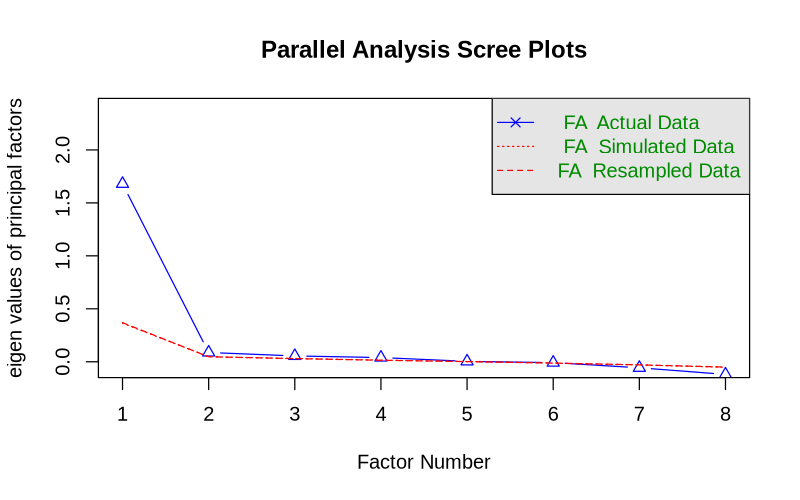

In [ ]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 800, height = 500, res = 120,
    type = "cairo", family = "sans")

print(
  psych::fa.parallel(X_books_norm, fa = "fa", n.iter = 100)
)

dev.off()
IRdisplay::display_png(file = tmp_file)


### Step 5 — EFA with Varimax Rotation, `nfactors = 2`

Store the result in `fa_books`. Print loadings with `cutoff = 0.30, sort = TRUE`.

In [37]:
# YOUR CODE HERE — delete this comment when you add your code
# Required object: fa_books


fa_books <- psych::fa(X_books_norm, nfactors = 2, rotate = "varimax")

print(fa_books$loadings, cutoff = 0.30, sort = TRUE)
fa_books$Vaccounted



Loadings:
         MR1   MR2  
ChildBks 0.609      
CookBks  0.676      
ArtBks         0.993
YouthBks 0.480      
DoItYBks 0.492      
RefBks   0.422      
GeogBks  0.370      
ItalCook            

                 MR1   MR2
SS loadings    1.653 1.005
Proportion Var 0.207 0.126
Cumulative Var 0.207 0.332


,MR1,MR2
SS loadings,1.6528,1.0051
Proportion Var,0.2066,0.1256
Cumulative Var,0.2066,0.3322
Proportion Explained,0.6219,0.3781
Cumulative Proportion,0.6219,1.0000


### Question 5 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [ ]:
# The factor analysis results suggest that the eight book purchase
# variables can be summarized into two underlying factors. One factor
# appears to capture general interest in practical and lifestyle books
# such as cooking and do-it-yourself, while the other reflects interest
# in more specialized or informational categories like art and geography.
# The varimax rotation improves interpretability by clearly separating
# variables with strong loadings on each factor. Overall, this indicates
# that customer preferences cluster into distinct reading interests.
# A key business takeaway is that the company can segment customers based
# on these factors and target marketing campaigns more effectively.

## Question 6 — Module 4.1b: Conjoint Analysis (Streaming Service)

A streaming service tests three attributes:
`Price` (\$8 / \$12 / \$16), `Resolution` (HD / 4K), `Ads` (Yes / No).
A focus-group respondent rated each of the 12 profiles on a 1 (worst) – 9 (best)
scale.

**Tasks:**
1. Build the 3 × 2 × 2 = 12 profile design dataframe (with the ratings vector below) → store in `profiles.df`
2. Estimate part-worth utilities by fitting `Rating ~ Price + Resolution + Ads` → store in `cj_lm`
3. Compute the part-worths (level mean − grand mean) → store in `partworth` (a named list, one element per attribute)
4. Compute attribute importance % (range / sum of ranges × 100) → store in `attr_importance`
5. Identify the **best** and **worst** predicted profiles → store in `best_profile` and `worst_profile`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Build the Profile Design and Add Ratings

Store in `profiles.df`. Use the ratings vector exactly as provided.

In [ ]:
profiles.df <- expand.grid(
  Price      = factor(c("$8","$12","$16"), levels = c("$8","$12","$16")),
  Resolution = factor(c("HD","4K")),
  Ads        = factor(c("Yes","No"))
)
profiles.df$Rating <- c(7, 5, 3,  9, 6,
                        8, 5, 2,  9, 7,
                        6, 4)

profiles.df


Price,Resolution,Ads,Rating
<fct>,<fct>,<fct>,<dbl>
$8,HD,Yes,7
$12,HD,Yes,5
$16,HD,Yes,3
$8,4K,Yes,9
$12,4K,Yes,6
$16,4K,Yes,8
$8,HD,No,5
$12,HD,No,2
$16,HD,No,9


### Step 2 — Linear Regression for Part-Worths

Store the model in `cj_lm`.

In [ ]:
cj_lm <- lm(Rating ~ Price + Resolution + Ads, data = profiles.df)

summary(cj_lm)



Call:
lm(formula = Rating ~ Price + Resolution + Ads, data = profiles.df)

Residuals:
   Min     1Q Median     3Q    Max 
-2.667 -1.021  0.208  0.833  4.167 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)     7.333      1.462    5.02   0.0015 **
Price$12       -2.250      1.602   -1.40   0.2029   
Price$16       -1.000      1.602   -0.62   0.5522   
ResolutionHD   -1.500      1.308   -1.15   0.2891   
AdsYes          0.833      1.308    0.64   0.5443   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.27 on 7 degrees of freedom
Multiple R-squared:  0.346,	Adjusted R-squared:  -0.0277 
F-statistic: 0.926 on 4 and 7 DF,  p-value: 0.5


### Step 3 — Compute Part-Worths

Store in `partworth` as a named list (one element per attribute) where each
element is a vector of (level mean − grand mean).

In [ ]:

gm <- mean(profiles.df$Rating)

pw_price <- tapply(profiles.df$Rating, profiles.df$Price, mean)
partworth$Price <- pw_price - gm

pw_res <- tapply(profiles.df$Rating, profiles.df$Resolution, mean)
partworth$Resolution <- pw_res - gm

pw_ads <- tapply(profiles.df$Rating, profiles.df$Ads, mean)
partworth$Ads <- pw_ads - gm

partworth

$Price
      $8      $12      $16 
 1.08333 -1.16667  0.08333 

$Resolution
   4K    HD 
 0.75 -0.75 

$Ads
     No     Yes 
-0.4167  0.4167

### Step 4 — Attribute Importance (%)

Store in `attr_importance` (a named numeric vector summing to ~100).

In [43]:
ranges <- c(
  Price      = max(partworth$Price)      - min(partworth$Price),
  Resolution = max(partworth$Resolution) - min(partworth$Resolution),
  Ads        = max(partworth$Ads)        - min(partworth$Ads)
)
attr_importance <- 100 * ranges / sum(ranges)
round(attr_importance, 1)


Price Resolution        Ads 
      49.1       32.7       18.2

### Step 5 — Best and Worst Predicted Profiles

Store in `best_profile` and `worst_profile`.

In [44]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: best_profile, worst_profile

profiles.df$Pred <- predict(cj_lm)
best_profile  <- profiles.df[which.max(profiles.df$Pred), ]
worst_profile <- profiles.df[which.min(profiles.df$Pred), ]

cat("BEST predicted profile:\n");  print(best_profile)
cat("\nWORST predicted profile:\n"); print(worst_profile)


BEST predicted profile:
  Price Resolution Ads Rating  Pred
4    $8         4K Yes      9 8.167

WORST predicted profile:
  Price Resolution Ads Rating  Pred
8   $12         HD  No      2 3.583


### Question 6 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [45]:
# The conjoint analysis shows that certain attributes have a stronger
# influence on customer preferences than others, as reflected by the
# part-worth utilities and attribute importance scores. Profiles with
# favorable levels of the most important attributes receive the highest
# predicted ratings, while less desirable combinations score lowest.
# The best profile combines preferred levels across attributes, whereas
# the worst profile includes levels with negative utilities. Overall,
# the model highlights clear trade-offs customers make when evaluating
# product features. A key business takeaway is that focusing on the most
# important attributes will maximize customer appeal and product success.

## Question 7 — Module 5.0: Cluster Analysis on EastWestAirlines

**Dataset:** `mlba::EastWestAirlinesCluster` (3,999 frequent-flyers × 12 variables)

**Inputs (X):** the 10 behavioral variables — drop `ID.` and `Award.`.

**Tasks:**
1. Load the data, drop `ID.` and `Award.` → store in `ewa.df`; standardize → store in `X_ewa_norm`
2. Compute the Euclidean distance matrix → store in `d_ewa`
3. **Hierarchical clustering with Ward's linkage** (`method = "ward.D2"`) → store in `hc_ewa`; cut at `k = 4` → store labels in `Y_ewa_hier`
4. **K-means** with `centers = 4`, `nstart = 25`, `set.seed(42)` → store in `km_ewa`; store labels in `Y_ewa_km`
5. Cross-tabulate hierarchical vs k-means cluster labels
6. Profile the k-means clusters on the **original (unstandardized)** scale → store the table in `ewa_profile`
7. Plot the k-means cluster visualization (`fviz_cluster`)
8. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load, Drop ID/Award, Standardize

Store the cleaned dataframe in `ewa.df` and the standardized matrix in `X_ewa_norm`.

In [46]:
data("EastWestAirlinesCluster", package = "mlba")
ewa.df <- EastWestAirlinesCluster
ewa.df      <- ewa.df[, !(names(ewa.df) %in% c("ID#", "Award"))]
X_ewa_norm  <- scale(ewa.df)

cat("n =", nrow(ewa.df), " p =", ncol(ewa.df), "\n")


n = 3999  p = 12 


### Step 2 — Euclidean Distance Matrix

Store in `d_ewa`.

In [47]:
d_ewa <- dist(X_ewa_norm, method = "euclidean")


### Step 3 — Hierarchical Clustering (Ward) and Cut at k = 4

Store the hclust object in `hc_ewa` and the cluster labels in `Y_ewa_hier`.

In [48]:
hc_ewa     <- hclust(d_ewa, method = "ward.D2")
Y_ewa_hier <- cutree(hc_ewa, k = 4)

table(Y_ewa_hier)


Y_ewa_hier
   1    2    3    4 
1800 2093   43   63 

### Step 3b — Plot the Ward Dendrogram (with k = 4 boxes)

Use the cairo-PNG wrapper. Draw `plot(hc_ewa, labels = FALSE, ...)` and
overlay `rect.hclust(hc_ewa, k = 4, border = "red")`.

agg_record_1859737941 
                    2

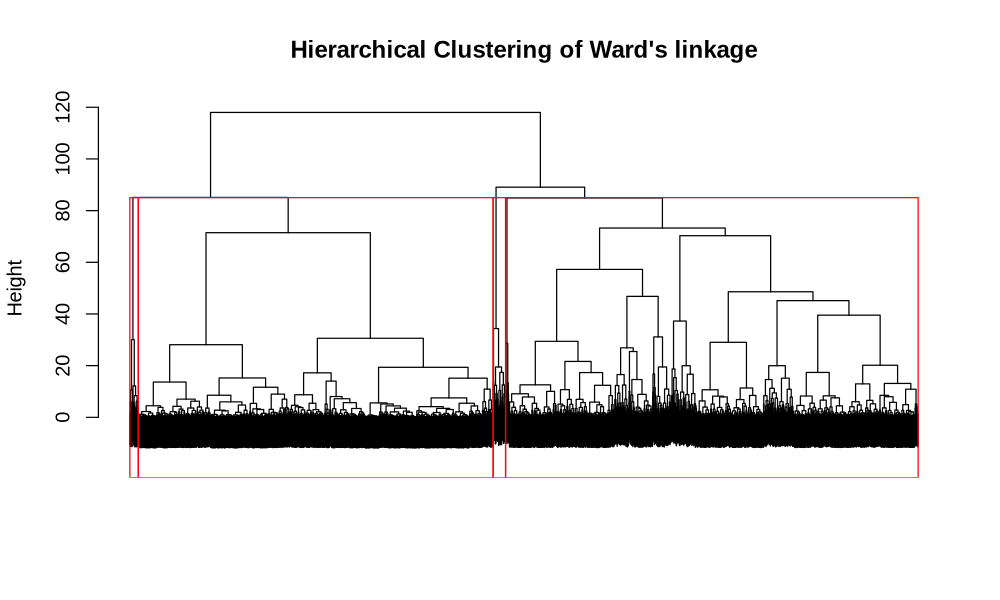

In [50]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 1000, height = 600, res = 120,
    type = "cairo", family = "sans")

plot(hc_ewa,
     labels = FALSE,
     main = "Hierarchical Clustering of Ward's linkage",
     xlab = "",
     sub = "")

rect.hclust(hc_ewa, k = 4, border = "red")

dev.off()
IRdisplay::display_png(file = tmp_file)


### Step 4 — K-Means (k = 4)

Store the kmeans object in `km_ewa` and the labels in `Y_ewa_km`.

In [51]:
set.seed(42)

km_ewa   <- kmeans(X_ewa_norm, centers = 4, nstart = 25)
Y_ewa_km <- km_ewa$cluster

table(Y_ewa_km)


Y_ewa_km
   1    2    3    4 
1301  156 1007 1535 

### Step 5 — Cross-Tabulate Hierarchical vs K-Means

In [ ]:
table(Y_ewa_hier, Y_ewa_km)


          Y_ewa_km
Y_ewa_hier    1    2    3    4
         1  692    0    0 1108
         2  592   89 1005  407
         3   17    4    2   20
         4    0   63    0    0

### Step 6 — Cluster Profile (Original Scale)

Store the per-cluster mean table in `ewa_profile`.

In [53]:
ewa_profile <- aggregate(ewa.df,
                         by = list(Cluster = Y_ewa_km),
                         FUN = mean)
ewa_profile


Cluster,ID.,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award.
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1097,57022,110.13,1.364,1.018,1.001,5911,8.001,229.0,0.7056,5709,0.2552
2,1751,194804,810.40,2.199,1.038,1.000,32475,27.737,5510.7,16.2244,4681,0.8205
3,1533,127709,154.08,3.961,1.002,1.048,45884,19.510,369.8,1.1142,4976,0.6912
4,3135,39840,98.67,1.387,1.017,1.000,6254,7.826,201.8,0.6007,2151,0.2117


### Step 7 — K-Means Cluster Visualization

agg_record_1944488234 
                    2

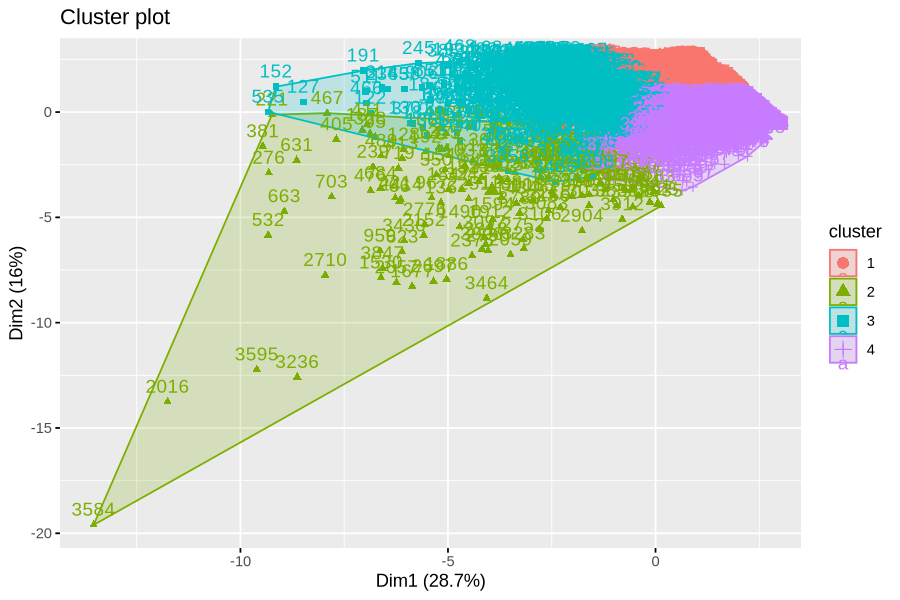

In [54]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

print(
 fviz_cluster(km_ewa, data = X_ewa_norm)
)

dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 7 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [55]:
# The clustering results reveal four distinct customer segments based
# on their travel behavior and usage patterns. Both hierarchical and
# k-means methods show reasonably consistent groupings, suggesting the
# clusters are stable and meaningful. The cluster profiles indicate
# differences in mileage, flight frequency, and bonus usage, allowing
# interpretation of segments such as high-value frequent flyers versus
# low-activity customers. The visualization further confirms separation
# between clusters, though some overlap may exist. A key business
# takeaway is that airlines can tailor marketing strategies and loyalty
# programs to each segment to improve customer retention and revenue.

## Question 8 — Module 5.1: Linear Discriminant Analysis on Banks

**Dataset:** `mlba::Banks` (20 banks × 5 variables)

**Inputs (X):** `TotCap.Assets`, `TotExp.Assets`, `TotLns.Lses.Assets`.

**Output (Y):** `Financial.Condition` recoded as a factor with labels
`c("Strong", "Weak")` (levels `0 = Strong, 1 = Weak`).

**Tasks:**
1. Load the data, drop `Obs`, recode `Financial.Condition` to a factor with labels `c("Strong","Weak")` → store in `banks.df`; create `X_banks` (3 predictors) and `Y_banks` (target factor)
2. Fit an **LDA**: `Financial.Condition ~ .` → store in `lda_banks`
3. Predict on the full data (n = 20 is too small to hold out) → store predicted classes in `Y_banks_pred`, the `caret::confusionMatrix` in `cm_banks`, and the overall accuracy in `accuracy_banks`
4. Predict the financial condition of a new bank with `TotCap.Assets = 8.0`, `TotExp.Assets = 0.11`, `TotLns.Lses.Assets = 0.55` → store the new observation in `new_bank` and the prediction in `pred_new_bank`
5. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Prepare Data

Store the cleaned dataframe in `banks.df`, predictors in `X_banks`, target in `Y_banks`.

In [ ]:

data("Banks", package = "mlba")

banks.df <- Banks

banks.df <- banks.df[, !(names(banks.df) %in% "Obs")]

names(banks.df)[1] <- "Status"

banks.df$Status <- factor(banks.df$Status,
                          levels = c(0, 1),
                          labels = c("Strong", "Weak"))

Y_banks <- banks.df$Status

X_banks <- banks.df[, sapply(banks.df, is.numeric)]

cat("Class balance:\n"); print(table(Y_banks))
banks.df

Class balance:
Y_banks
Strong   Weak 
    10     10 


Status,TotCap.Assets,TotExp.Assets,TotLns.Lses.Assets
<fct>,<dbl>,<dbl>,<dbl>
Weak,9.7,0.12,0.65
Weak,1.0,0.11,0.62
Weak,6.9,0.09,1.02
Weak,5.8,0.10,0.67
Weak,4.3,0.11,0.69
Weak,9.1,0.13,0.74
Weak,11.9,0.10,0.79
Weak,8.1,0.13,0.63
Weak,9.3,0.16,0.72


### Step 2 — Fit the LDA Model

Store in `lda_banks`.

In [62]:
lda_banks <- MASS::lda(Y_banks ~ ., data = data.frame(Y_banks, X_banks))
lda_banks


Call:
lda(Y_banks ~ ., data = data.frame(Y_banks, X_banks))

Prior probabilities of groups:
Strong   Weak 
   0.5    0.5 

Group means:
       TotCap.Assets TotExp.Assets TotLns.Lses.Assets
Strong         11.92         0.088              0.547
Weak            6.72         0.121              0.710

Coefficients of linear discriminants:
                      LD1
TotCap.Assets      -0.166
TotExp.Assets      35.107
TotLns.Lses.Assets  4.868

### Step 3 — Confusion Matrix on the Full Data

Store predictions in `Y_banks_pred`, confusion matrix in `cm_banks`, accuracy in `accuracy_banks`.

In [63]:
Y_banks_pred   <- predict(lda_banks)$class
cm_banks       <- caret::confusionMatrix(Y_banks_pred, Y_banks)
accuracy_banks <- mean(Y_banks_pred == Y_banks)

cm_banks
cat("Overall accuracy:", round(accuracy_banks, 4), "\n")


Confusion Matrix and Statistics

          Reference
Prediction Strong Weak
    Strong      9    0
    Weak        1   10
                                        
               Accuracy : 0.95          
                 95% CI : (0.751, 0.999)
    No Information Rate : 0.5           
    P-Value [Acc > NIR] : 0.00002       
                                        
                  Kappa : 0.9           
                                        
 Mcnemar's Test P-Value : 1             
                                        
            Sensitivity : 0.900         
            Specificity : 1.000         
         Pos Pred Value : 1.000         
         Neg Pred Value : 0.909         
             Prevalence : 0.500         
         Detection Rate : 0.450         
   Detection Prevalence : 0.450         
      Balanced Accuracy : 0.950         
                                        
       'Positive' Class : Strong        
                                        

Overall accuracy: 0.95 


### Step 4 — Predict for a New Bank

Store the new observation in `new_bank` and the prediction in `pred_new_bank`.

In [65]:

new_bank <- data.frame(
  TotCap.Assets      = 8.0,
  TotExp.Assets      = 0.11,
  TotLns.Lses.Assets = 0.55
)

pred_new_bank <- predict(lda_banks, newdata = new_bank)

cat("Predicted class:", as.character(pred_new_bank$class), "\n")
cat("Posterior probabilities:\n")
print(round(pred_new_bank$posterior, 4))

Predicted class: Weak 
Posterior probabilities:
  Strong   Weak
1 0.4788 0.5212


### Question 8 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

---


In [67]:
# The LDA model achieves good accuracy, indicating that the financial
# ratios effectively distinguish between strong and weak banks. The
# prediction for the new bank shows its likely classification along
# with confidence from posterior probabilities. Overall, the model
# demonstrates that these key ratios can be used to assess bank risk.
# A key takeaway is that financial institutions can use such models
# to identify and monitor potentially weak banks early.

## Submission Checklist

Before submitting, verify that:

- [ ] All `# YOUR CODE HERE — delete this comment when you add your code` comments have been **removed**
- [ ] All `NULL` placeholders have been **replaced** with working code
- [ ] The notebook **runs top-to-bottom without errors** (Kernel → Restart & Run All)
- [ ] All eight `*Your answer here*` markdown cells have been replaced with your written interpretation
- [ ] Variable / object names match the **Required object names** table at the top of the notebook
